In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
np.random.seed(42)

def true_function(x):
    return np.sin(1.5*np.pi*x)

n_samples = 200

X = np.sort(np.random.rand(n_samples))
y = true_function(X) + np.random.normal(0,0.25,n_samples)

X = X.reshape(-1,1)

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.3,random_state=42
)

Part A

In [3]:
tree=DecisionTreeRegressor(max_depth=None,random_state=42)

tree.fit(X_train,y_train)

train_pred=tree.predict(X_train)
test_pred=tree.predict(X_test)

print("Train MSE:",mean_squared_error(y_train,train_pred))
print("Test MSE:",mean_squared_error(y_test,test_pred))

Train MSE: 0.0
Test MSE: 0.12051834094061427


Observation -
Train error is very low.
Test error is higher.

In [4]:
depths=[1,2,3,5,8,12,None]

train_mse=[]
test_mse=[]

for d in depths:

    model=DecisionTreeRegressor(max_depth=d,random_state=42)

    model.fit(X_train,y_train)

    train_mse.append(
        mean_squared_error(y_train,model.predict(X_train))
    )

    test_mse.append(
        mean_squared_error(y_test,model.predict(X_test))
    )

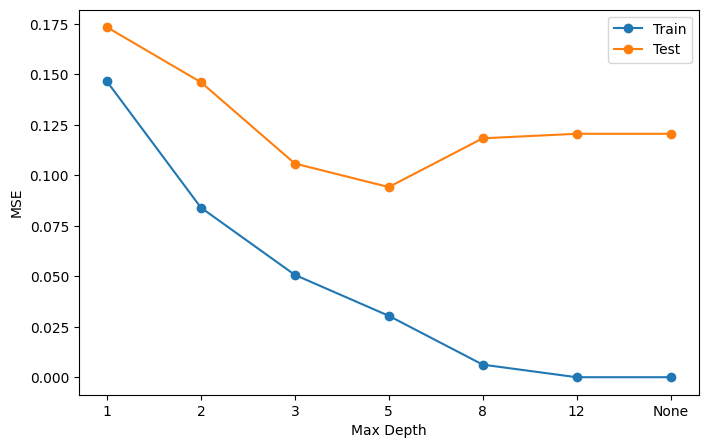

In [5]:
labels=['1','2','3','5','8','12','None']

plt.figure(figsize=(8,5))

plt.plot(labels,train_mse,marker='o',label='Train')

plt.plot(labels,test_mse,marker='o',label='Test')

plt.xlabel("Max Depth")
plt.ylabel("MSE")
plt.legend()

plt.show()

Q1. At max_depth=1, is the model biased or high variance?

Answer:

The model has high bias because it is too simple and cannot learn the data properly.

Q2. At max_depth=None what happens?

Answer:

Train MSE becomes very small but Test MSE is larger. This means the model is overfitting.

Part B

In [6]:
rf=RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

train_pred=rf.predict(X_train)
test_pred=rf.predict(X_test)

print("Train MSE:",mean_squared_error(y_train,train_pred))
print("Test MSE:",mean_squared_error(y_test,test_pred))

Train MSE: 0.010460801202758248
Test MSE: 0.1012343548315342


Observation -

Random Forest gives better Test MSE than a single Decision Tree.

In [7]:
trees=[1,5,10,20,50,100,200]

train=[]
test=[]

for n in trees:

    model=RandomForestRegressor(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train,y_train)

    train.append(
        mean_squared_error(y_train,model.predict(X_train))
    )

    test.append(
        mean_squared_error(y_test,model.predict(X_test))
    )

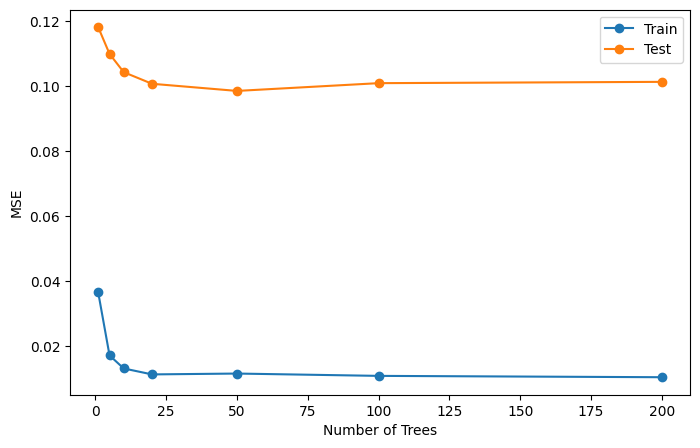

In [8]:
plt.figure(figsize=(8,5))

plt.plot(trees,train,marker='o',label='Train')

plt.plot(trees,test,marker='o',label='Test')

plt.xlabel("Number of Trees")

plt.ylabel("MSE")

plt.legend()

plt.show()

Why does Test MSE improve as trees increase?

More trees reduce random errors and improve prediction. After some point the improvement becomes very small.

Does adding more trees cause overfitting?

No.

Random Forest averages many trees, so adding more trees usually reduces variance instead of increasing overfitting.

Part C

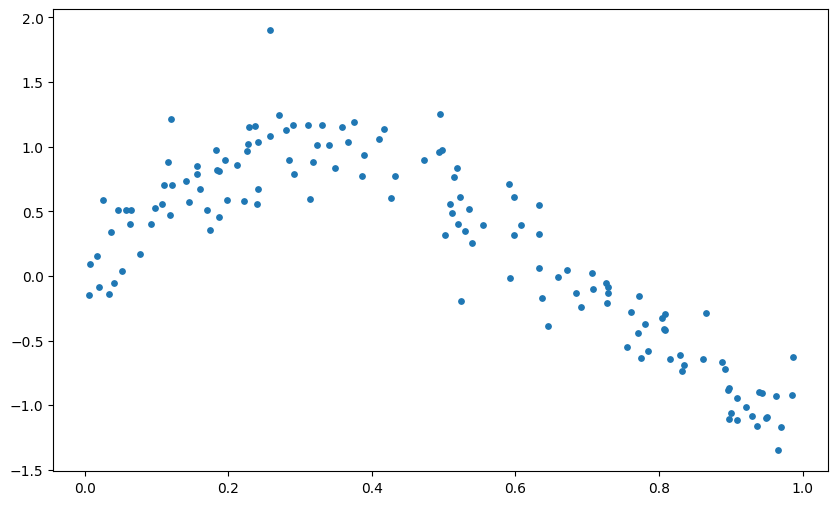

In [9]:
x_plot=np.linspace(0,1,300).reshape(-1,1)

plt.figure(figsize=(10,6))

plt.scatter(X_train,y_train,s=15)

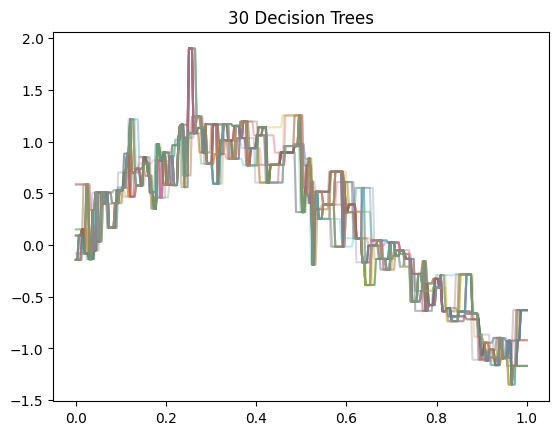

In [10]:
for i in range(30):

    sample=np.random.choice(
        len(X_train),
        len(X_train),
        replace=True
    )

    X_boot=X_train[sample]
    y_boot=y_train[sample]

    model=DecisionTreeRegressor(random_state=i)

    model.fit(X_boot,y_boot)

    plt.plot(
        x_plot,
        model.predict(x_plot),
        alpha=0.3
    )

plt.title("30 Decision Trees")

plt.show()

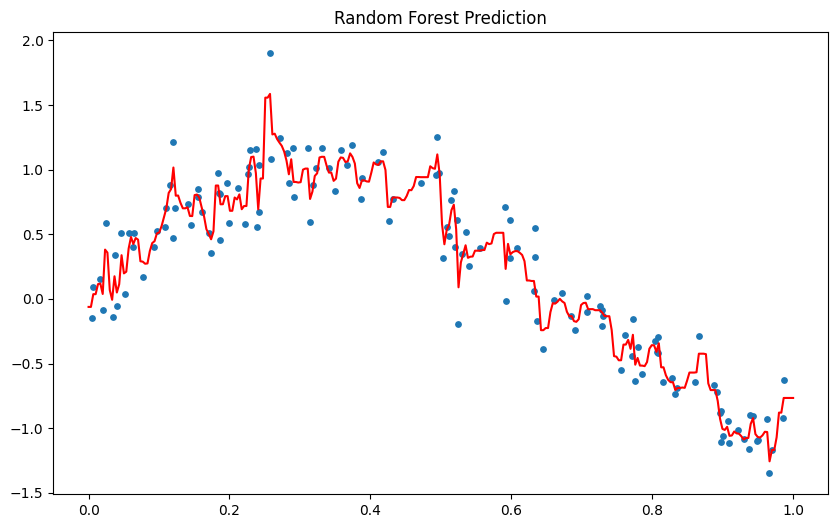

In [11]:
rf=RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

plt.figure(figsize=(10,6))

plt.scatter(X_train,y_train,s=15)

plt.plot(
    x_plot,
    rf.predict(x_plot),
    color='red'
)

plt.title("Random Forest Prediction")

plt.show()

Which graph shows more variance?

The Decision Tree graph shows more variance because every tree gives a different prediction.

Which model is closer to the true function?

Random Forest is closer to the true function because it averages many trees.

Why does Random Forest reduce variance?

Random Forest builds many Decision Trees using different bootstrap samples. Each tree makes its own prediction. The final prediction is the average of all trees. Averaging reduces random errors and gives a more stable prediction. This is why Random Forest usually performs better than a single Decision Tree.

Final Conclusion -
A shallow Decision Tree has high bias.
A fully grown Decision Tree overfits the data.
Random Forest gives better Test MSE.
Increasing the number of trees improves performance up to a point.
Random Forest reduces variance by averaging many Decision Trees.